In [46]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")

In [47]:
# Requirement 1
print(df.head())
print(df.shape)
df.info()
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

## Dataset Description

The Titanic dataset contains information about 891 passengers, including their age, gender, ticket class, fare, and survival status. During the initial inspection, I observed that the dataset has both numerical and categorical columns, along with some missing values that will need to be handled during data cleaning.

### Questions to Explore

1. Does passenger class affect rates of survival?
2. Did gender influence chance of survival?
3. Is there a relationship between age or fare with survival?

In [48]:
# Requirement 2
print(df.isna().sum()) # check missing values

df["Age"] = df["Age"].fillna(df["Age"].median()) # age has missing values, fill with median age

df = df.drop(columns=["Cabin"]) # many missing values, so drop cabin

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [49]:
# Requirement 3
young_survivors = df[(df["Age"] < 18) & (df["Survived"] == 1)]
print(young_survivors.head())

    PassengerId  Survived  Pclass                                      Name  \
9            10         1       2       Nasser, Mrs. Nicholas (Adele Achem)   
10           11         1       3           Sandstrom, Miss. Marguerite Rut   
22           23         1       3               McGowan, Miss. Anna "Annie"   
39           40         1       3               Nicola-Yarred, Miss. Jamila   
43           44         1       2  Laroche, Miss. Simonne Marie Anne Andree   

       Sex   Age  SibSp  Parch         Ticket     Fare Embarked  
9   female  14.0      1      0         237736  30.0708        C  
10  female   4.0      1      1        PP 9549  16.7000        S  
22  female  15.0      0      0         330923   8.0292        Q  
39  female  14.0      1      0           2651  11.2417        C  
43  female   3.0      1      2  SC/Paris 2123  41.5792        C  


In [51]:
import numpy as np
# Requirement 4
df["Age_group"] = df["Age"].apply(lambda x: "Child" if x < 18 else "Adult")

# Requirement 5
def family_size_category(size):
    if size == 0:
        return "Alone"
    elif size <= 3:
        return "Small family"
    else:
        return "Large family"

df["Family_Category"] = (df["SibSp"] + df["Parch"]).apply(family_size_category)

# Requirement 6
df["Is_Child"] = np.where(df["Age"] < 18, 1, 0)

print(df[["Age", "Age_group"]].head())
print(df[["Age", "Is_Child"]].head())

    Age Age_group
0  22.0     Adult
1  38.0     Adult
2  26.0     Adult
3  35.0     Adult
4  35.0     Adult
    Age  Is_Child
0  22.0         0
1  38.0         0
2  26.0         0
3  35.0         0
4  35.0         0


In [52]:
# Requirement 7
df.sort_values(by=["Pclass", "Fare"],ascending=[True, False]).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_group,Family_Category,Is_Child
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,Adult,Alone,0
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,Adult,Small family,0
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,Adult,Alone,0
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S,Adult,Large family,0
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S,Adult,Large family,0


In [53]:
# Requirement 8
df.groupby("Sex")["Survived"].mean()
print(df.groupby("Sex")["Survived"].mean())

# Requirement 9
df.groupby("Pclass")["Fare"].agg(["mean", "min", "max", "count"])
print(df.groupby("Pclass")["Fare"].agg(["mean", "min", "max", "count"]))

# Requirement 10
survival_class = (df.groupby("Pclass")["Survived"].mean().reindex([1, 2, 3]))
print(survival_class)


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
             mean  min       max  count
Pclass                                 
1       84.154687  0.0  512.3292    216
2       20.662183  0.0   73.5000    184
3       13.675550  0.0   69.5500    491
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [41]:
# Requirement 15
numeric_cols = [col for col in df.columns if df[col].dtype != "object"]
print(numeric_cols)

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Is_Child']


In [54]:
# Requirement 3
# Create age group
df["Age_group"] = pd.cut(df["Age"], bins=[0, 18, 35, 60, 100], labels=["Child", "Young adult", "Adult", "Senior"])
print(df[["Age", "Age_group"]].head())

    Age    Age_group
0  22.0  Young adult
1  38.0        Adult
2  26.0  Young adult
3  35.0  Young adult
4  35.0  Young adult


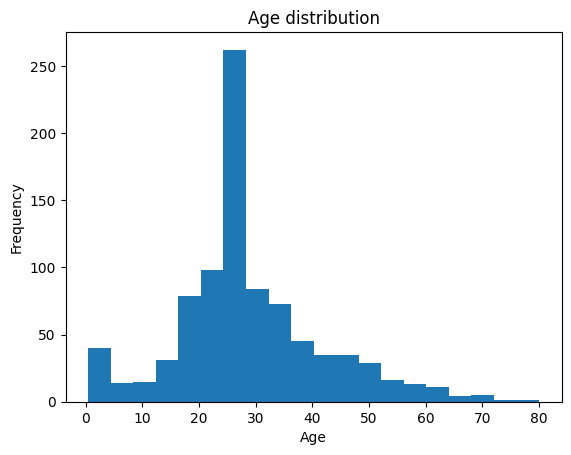

In [55]:
#Requirement 13
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=20)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Interpretation: The age distribution is slightly right skewed because most passengers are of age between 20 and 30 years old

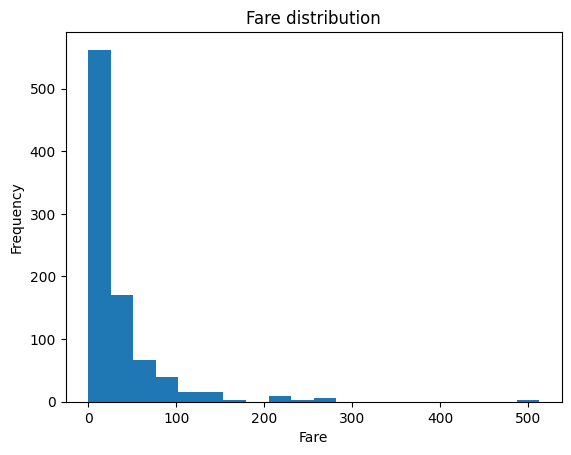

In [56]:
#Requirement 13

plt.hist(df["Fare"], bins=20)
plt.title("Fare distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

Interpretation: Fare is right-skewed because a small number of passengers paid very high ticket prices.

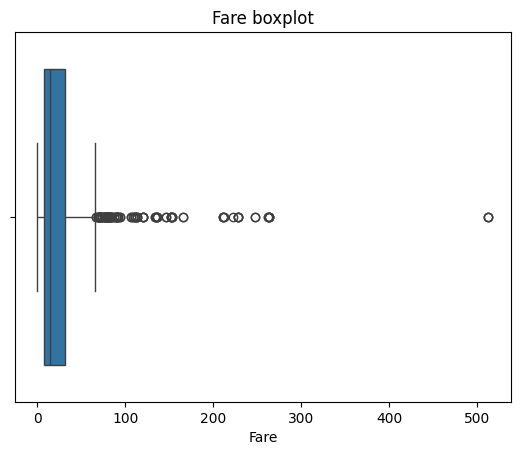

In [57]:
#Requirement 12
import seaborn as sns

sns.boxplot(x=df["Fare"])
plt.title("Fare boxplot")
plt.show()

In [9]:
# IQR Method
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Fare"] < Q1 - 1.5 * IQR) | (df["Fare"] > Q3 + 1.5 * IQR)]
print("Number of outliers:", len(outliers))

Number of outliers: 116


Interpretation: Several passengers have high fares compared to the rest of the dataset.

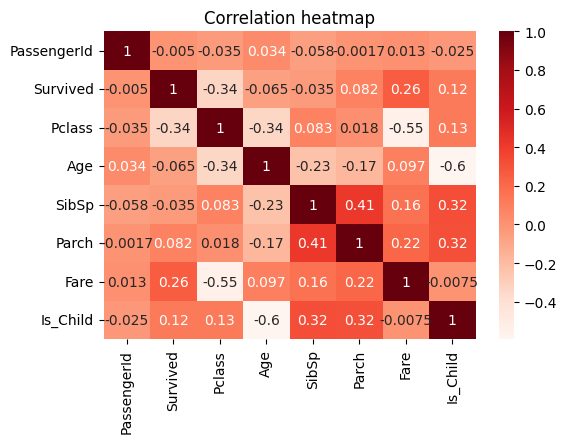

In [58]:
#Requirement 11
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Reds")
plt.title("Correlation heatmap")
plt.show()

Interpretation: Survival shows a positive relationship with Fare and a negative relationship with Pclass

In [59]:
#Requirement 10
survival_by_gender = df.groupby("Sex")["Survived"].agg(["mean", "count"])
print(survival_by_gender)

            mean  count
Sex                    
female  0.742038    314
male    0.188908    577


Interpretation: Females had a higher survival rate than male passengers, means gender played a significant role in survival outcomes.

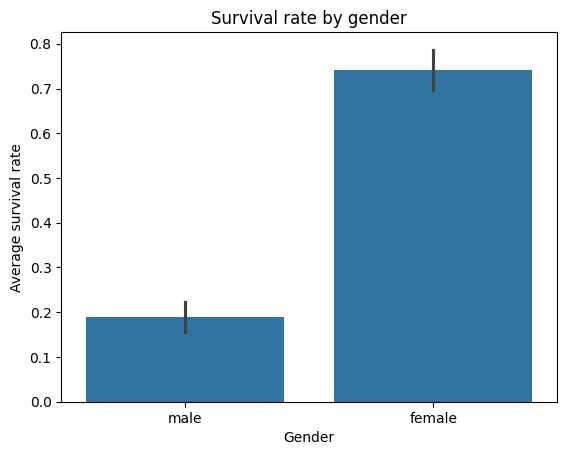

In [23]:
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival rate by gender")
plt.xlabel("Gender")
plt.ylabel("Average survival rate")
plt.show()

Interpretation: Female passengers had higher survival rate than male passenger

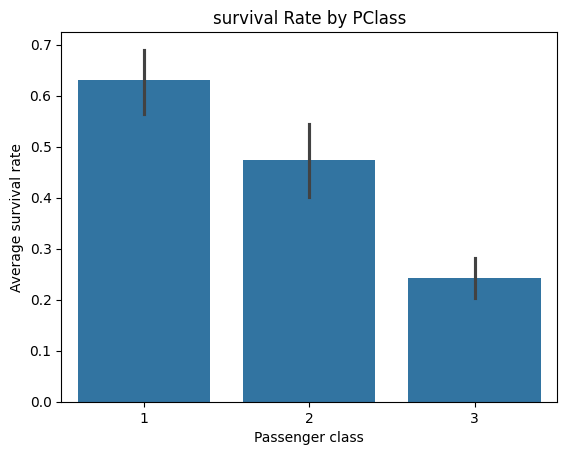

In [24]:
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("survival Rate by PClass")
plt.xlabel("Passenger class")
plt.ylabel("Average survival rate")
plt.show()

Interpretation: Passengers in first class had the highest survival rate, while those in third class had the lowest.

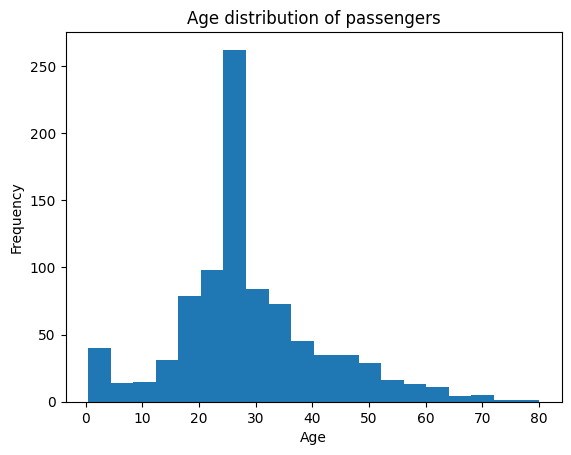

In [25]:
plt.hist(df["Age"], bins=20)
plt.title("Age distribution of passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Interpretation: Most people were between 20 - 30 years old. The distribution is right-skewed.

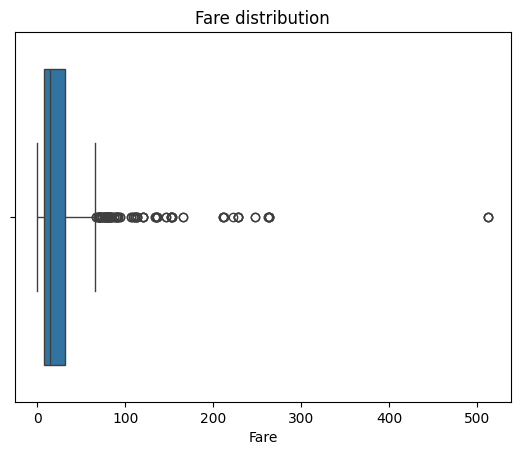

In [26]:
sns.boxplot(x=df["Fare"])
plt.title("Fare distribution")
plt.xlabel("Fare")
plt.show()

Interpretation: The boxplot reveals fare values that are much higher than the majority of ticket prices, suggesting that a small group of passengers paid significantly more.

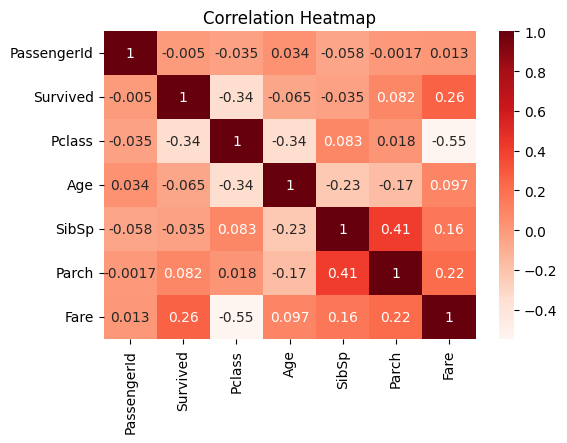

In [28]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Reds")
plt.title("Correlation Heatmap")
plt.show()

Interpretation: The heatmap shows that survival has a positive correlation with fare and a negative correlation with passenger class.

##conclusion:
### Question 1: Does passenger class affect rates of survival?

Yes, passenger class appears to affect survival rates. Passengers in first class had a higher chance of survival compared to those in second and third class. This suggests that passengers in higher classes were in a better position to access safety measures during the disaster.

### Question 2: Did gender influence chance of survival?

Yes, gender had a strong influence on survival. Female passengers survived at a much higher rate than male passengers. The data supports the idea that women were given priority during the evacuation process.

### Question 3: Is there a relationship between age or fare with survival?

The analysis shows that fare has some relationship with survival, as passengers who paid higher fares generally had better survival rates. while age does not show a clear pattern, so the data does not strongly support age as a major factor affecting survival.
